# **Module 3 :— MEDICAL REPORT EXPLAINER**
### MedAI Nexus | OCR + Gemini 1.5 Flash
---
**Dataset:** [Bajaj Medical Lab Reports (Kaggle)](https://www.kaggle.com/datasets/dikshaasinghhh/bajaj)  
**Model:** Tesseract OCR (LSTM-based Text Extraction) + Gemini 1.5 Flash (LLM for Medical Text Understanding & Interpretation) <br>
**Task:** Extract text from scanned lab reports and generate patient-friendly explanations <br> <br>
**Goal:** Image → pytesseract OCR → GPT-4o → Plain-language report  

Upload Image → Preprocess → OCR → Clean → Gemini → Validate → Display (Streamlit)

## 1. Install & Import Dependencies
---

In [1]:
!pip install openai pytesseract pillow pdf2image opencv-python -q
!apt-get install -y tesseract-ocr poppler-utils -q


Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched 186 kB in 1s (333 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...


In [2]:
import os
import re
import json
import shutil
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import cv2
import pytesseract
from pdf2image import convert_from_path
from openai import OpenAI

# Verify tesseract is installed correctly
try:
    version = pytesseract.get_tesseract_version()
    print(f"[OK] Tesseract installed. Version: {version}")
except Exception as e:
    print(f"[ERROR] Tesseract not found: {e}")

print("All libraries loaded.")

[OK] Tesseract installed. Version: 4.1.1
All libraries loaded.


## 2. Load Dataset from Drive
---

In [3]:
import os
from google.colab import drive
drive.mount('/content/drive')

# ── UPDATE THIS PATH ──────────────────────────────────────────────────────────
REPORTS_DIR  = "/content/drive/MyDrive/datasets/labreport"
OUTPUT_DIR   = "/content/bajaj_processed"      # local working dir
CLEANED_DIR  = "/content/bajaj_cleaned_images" # preprocessed images
TEXT_DIR     = "/content/bajaj_extracted_text" # OCR text outputs

for d in [OUTPUT_DIR, CLEANED_DIR, TEXT_DIR]:
    os.makedirs(d, exist_ok=True)

if os.path.exists(REPORTS_DIR):
    print(f"[OK] Reports directory found: {REPORTS_DIR}")
else:
    print(f"[ERROR] Directory not found: {REPORTS_DIR}")
    print("        Please update REPORTS_DIR above.")

VALID_IMG  = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}
VALID_ALL  = VALID_IMG | {'.pdf'}

Mounted at /content/drive
[OK] Reports directory found: /content/drive/MyDrive/datasets/labreport


## 3. Collect All Report Files
---
Find every image and PDF in your reports folder.

In [4]:
def collect_files(directory):
    """Recursively find all valid report files in a folder."""
    files = []
    for root, _, fnames in os.walk(directory):
        for fname in fnames:
            fpath = Path(root) / fname
            if fpath.suffix.lower() in VALID_ALL:
                files.append(fpath)
    return sorted(files)

all_files = collect_files(REPORTS_DIR)

# Build a summary table
inventory = pd.DataFrame({
    'filename'  : [f.name for f in all_files],
    'extension' : [f.suffix.lower() for f in all_files],
    'size_kb'   : [round(f.stat().st_size / 1024, 1) for f in all_files],
    'full_path' : [str(f) for f in all_files],
})

print(f"Total files found : {len(inventory)}")
print(f"File types        :")
print(inventory['extension'].value_counts().to_string())
print(f"\nSize range        : {inventory['size_kb'].min()} KB — {inventory['size_kb'].max()} KB")
print()
print("First 5 files:")
print(inventory[['filename','extension','size_kb']].head().to_string(index=False))

Total files found : 425
File types        :
extension
.png    425

Size range        : 169.8 KB — 21546.8 KB

First 5 files:
                                                                               filename extension  size_kb
                             AHD-0425-PA-0007719_E-REPORTS_250427_2032@E.pdf_page_4.png      .png   1071.1
                             AHD-0425-PA-0007719_E-REPORTS_250427_2032@E.pdf_page_7.png      .png   1751.4
         AHD-0425-PA-0008061_E-mahendrasinghdischargecard_250427_1114@E.pdf_page_13.png      .png   2075.1
         AHD-0425-PA-0008061_E-mahendrasinghdischargecard_250427_1114@E.pdf_page_27.png      .png   1818.4
BLR-0425-PA-0036693_ARVIND REDDY REPALA 0036693_28-04-2025_1120-45_AM@E.pdf_page_24.png      .png   1710.3


In [5]:
def assess_image_quality(img_path):
    """
    Assess a single image for OCR suitability.
    Returns a dict of quality metrics.
    """
    metrics = {
        'path'          : str(img_path),
        'filename'      : Path(img_path).name,
        'readable'      : False,
        'width'         : None,
        'height'        : None,
        'mode'          : None,
        'brightness_mean': None,
        'contrast_std'  : None,
        'blur_score'    : None,  # Laplacian variance — higher = sharper
        'issues'        : [],
    }

    try:
        img = Image.open(img_path).convert('RGB')
        metrics['readable'] = True
        metrics['width']    = img.width
        metrics['height']   = img.height
        metrics['mode']     = img.mode

        arr   = np.array(img.convert('L'), dtype=np.float32)  # grayscale
        metrics['brightness_mean'] = float(arr.mean())
        metrics['contrast_std']    = float(arr.std())

        # Blur detection using Laplacian variance
        lap   = cv2.Laplacian(arr.astype(np.uint8), cv2.CV_64F)
        metrics['blur_score'] = float(lap.var())

        # Flag issues
        if img.width < 300 or img.height < 300:
            metrics['issues'].append('low_resolution')
        if metrics['brightness_mean'] < 50:
            metrics['issues'].append('too_dark')
        if metrics['brightness_mean'] > 220:
            metrics['issues'].append('overexposed')
        if metrics['blur_score'] < 50:
            metrics['issues'].append('blurry')
        if metrics['contrast_std'] < 20:
            metrics['issues'].append('low_contrast')

    except Exception as e:
        metrics['issues'].append(f'error: {str(e)}')

    return metrics

# Assess all image files (skip PDFs for now)
img_files = [
    f for f in all_files
    if Path(f).suffix.lower() in VALID_IMG
]

print(f"Assessing {len(img_files)} image files...")
quality_data = []
for i, fpath in enumerate(img_files):
    quality_data.append(assess_image_quality(fpath))
    if (i + 1) % 20 == 0:
        print(f"  Done {i+1}/{len(img_files)}")

quality_df = pd.DataFrame(quality_data)
print(f"\nAssessment complete.")
print(f"Readable images      : {quality_df['readable'].sum()}")
print(f"Unreadable images    : {(~quality_df['readable']).sum()}")
print(f"Images with issues   : {(quality_df['issues'].apply(len) > 0).sum()}")


Assessing 425 image files...
  Done 20/425
  Done 40/425
  Done 60/425
  Done 80/425
  Done 100/425
  Done 120/425
  Done 140/425
  Done 160/425
  Done 180/425
  Done 200/425
  Done 220/425
  Done 240/425
  Done 260/425
  Done 280/425
  Done 300/425
  Done 320/425
  Done 340/425
  Done 360/425
  Done 380/425
  Done 400/425
  Done 420/425

Assessment complete.
Readable images      : 425
Unreadable images    : 0
Images with issues   : 335


── Image Quality Statistics ────────────────────────────────
Resolution — min: 867x2025, max: 5425x8117, mean: 1652x2328
Brightness — mean: 229.8  (ideal: 100-200)
Contrast   — std : 58.6     (ideal: >30)
Blur score — mean: 1272.8       (ideal: >100)

Issues detected:
  overexposed         : 335 images


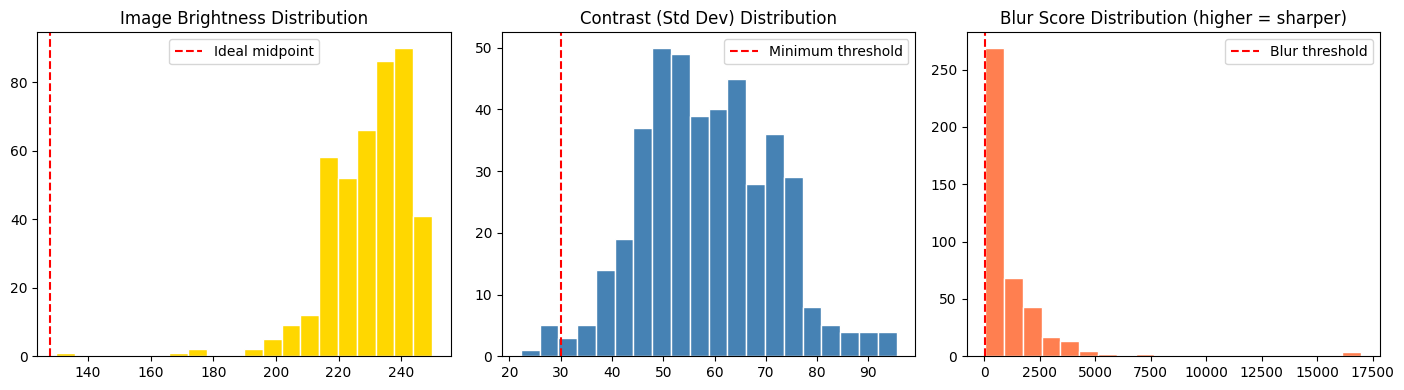

In [6]:
# Show quality statistics
readable_df = quality_df[quality_df['readable']].copy()

if len(readable_df) > 0:
    print("── Image Quality Statistics ────────────────────────────────")
    print(f"Resolution — min: {readable_df['width'].min()}x{readable_df['height'].min()}, "
          f"max: {readable_df['width'].max()}x{readable_df['height'].max()}, "
          f"mean: {readable_df['width'].mean():.0f}x{readable_df['height'].mean():.0f}")
    print(f"Brightness — mean: {readable_df['brightness_mean'].mean():.1f}  (ideal: 100-200)")
    print(f"Contrast   — std : {readable_df['contrast_std'].mean():.1f}     (ideal: >30)")
    print(f"Blur score — mean: {readable_df['blur_score'].mean():.1f}       (ideal: >100)")

    # Issue breakdown
    all_issues = []
    for issues_list in readable_df['issues']:
        all_issues.extend(issues_list)

    if all_issues:
        issue_counts = pd.Series(all_issues).value_counts()
        print("\nIssues detected:")
        for issue, count in issue_counts.items():
            print(f"  {issue:<20}: {count} images")
    else:
        print("\n[OK] No quality issues detected.")

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].hist(readable_df['brightness_mean'].dropna(), bins=20, color='gold', edgecolor='white')
    axes[0].set_title('Image Brightness Distribution')
    axes[0].axvline(128, color='red', linestyle='--', label='Ideal midpoint')
    axes[0].legend()
    axes[1].hist(readable_df['contrast_std'].dropna(), bins=20, color='steelblue', edgecolor='white')
    axes[1].set_title('Contrast (Std Dev) Distribution')
    axes[1].axvline(30, color='red', linestyle='--', label='Minimum threshold')
    axes[1].legend()
    axes[2].hist(readable_df['blur_score'].dropna(), bins=20, color='coral', edgecolor='white')
    axes[2].set_title('Blur Score Distribution (higher = sharper)')
    axes[2].axvline(50, color='red', linestyle='--', label='Blur threshold')
    axes[2].legend()
    plt.tight_layout()
    plt.savefig('quality_assessment.png', dpi=150)
    plt.show()


## 4. PDF to Image Conversion
---



In [7]:
def convert_pdfs_to_images(pdf_files, output_dir, dpi=300):
    """
    Convert each page of each PDF to a JPEG image.

    Args:
        pdf_files  : list of PDF file paths
        output_dir : where to save the images
        dpi        : resolution (300 recommended for OCR)

    Returns:
        list of image paths created
    """
    image_paths = []

    for pdf_path in pdf_files:
        stem = Path(pdf_path).stem      # filename without extension
        print(f"  Converting: {Path(pdf_path).name}")

        try:
            # convert_from_path renders each PDF page as a PIL Image
            pages = convert_from_path(str(pdf_path), dpi=dpi)

            for page_num, page_img in enumerate(pages):
                # Save as JPEG with 95% quality (high quality = better OCR)
                out_name = f"{stem}_page{page_num + 1}.jpg"
                out_path = os.path.join(output_dir, out_name)
                page_img.save(out_path, 'JPEG', quality=95)
                image_paths.append(out_path)

        except Exception as e:
            print(f"  [ERROR] {Path(pdf_path).name}: {e}")

    return image_paths

# Convert all PDFs
pdf_files = [f for f in all_files if f.suffix.lower() == '.pdf']
print(f"Found {len(pdf_files)} PDF files. Converting...")

converted_images = convert_pdfs_to_images(pdf_files, CLEANED_DIR)
print(f"\nCreated {len(converted_images)} images from PDFs.")

# Combine: original images + converted PDF pages
original_images = [str(f) for f in all_files if f.suffix.lower() in VALID_IMG]
all_image_paths  = original_images + converted_images
print(f"Total images to process: {len(all_image_paths)}")

Found 0 PDF files. Converting...

Created 0 images from PDFs.
Total images to process: 425


## 5. Image Preprocessing for Better OCR
---
Each image goes through 5 steps to maximise OCR accuracy:
1. **Grayscale** — removes colour (irrelevant for text, adds noise)
2. **Denoise** — removes scanner grain
3. **CLAHE** — fixes uneven lighting across the page which iscommon in scanned reports(dark edges, bright centre)
4. **Binarise** — makes text pure black on pure white
5. **Deskew** — straightens tilted pages by roatating pages dramatically reduce OCR accuracy

Demonstrating preprocessing on: AHD-0425-PA-0007719_E-REPORTS_250427_2032@E.pdf_page_4.png


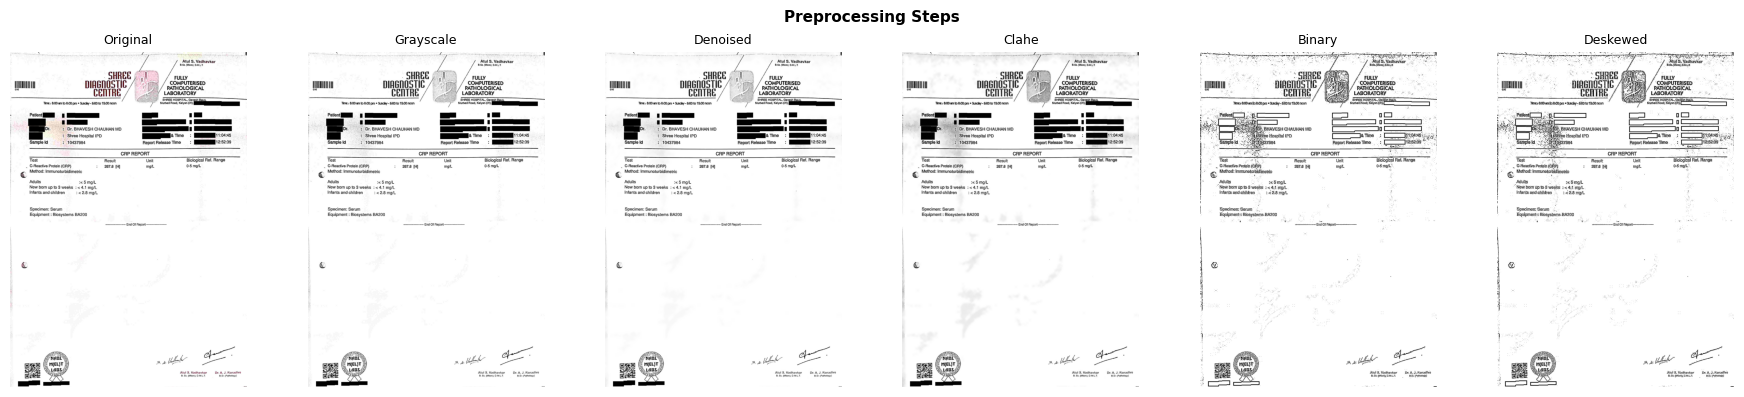

Saved: preprocessing_steps.png


In [8]:
def preprocess_for_ocr(image_path, save_path=None, show_steps=False):
    """
    Full preprocessing pipeline for OCR.

    Args:
        image_path : str   — path to input image
        save_path  : str   — if given, saves the processed image here
        show_steps : bool  — if True, displays intermediate steps

    Returns:
        np.ndarray — preprocessed binary image ready for Tesseract
    """
    # ── Load ──────────────────────────────────────────────────────────────────
    img = cv2.imread(str(image_path))
    if img is None:
        pil_img = Image.open(image_path).convert('RGB')
        img     = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

    steps = {'original': cv2.cvtColor(img, cv2.COLOR_BGR2RGB)}

    # ── Step 1: Grayscale ─────────────────────────────────────────────────────
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    steps['grayscale'] = gray

    # ── Step 2: Denoise ───────────────────────────────────────────────────────
    # h=10 removes noise without blurring text
    denoised = cv2.fastNlMeansDenoising(gray, h=10, templateWindowSize=7, searchWindowSize=21)
    steps['denoised'] = denoised

    # ── Step 3: CLAHE (Contrast Enhancement) ─────────────────────────────────
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)
    steps['clahe'] = enhanced

    # ── Step 4: Adaptive Binarisation ────────────────────────────────────────
    # Adaptive threshold handles shadows better than global threshold
    binary = cv2.adaptiveThreshold(
        enhanced,
        maxValue    = 255,
        adaptiveMethod  = cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        thresholdType   = cv2.THRESH_BINARY,
        blockSize   = 11,   # local neighbourhood size (must be odd)
        C           = 2     # constant subtracted from mean
    )
    steps['binary'] = binary

    # ── Step 5: Deskew ────────────────────────────────────────────────────────
    coords = np.column_stack(np.where(binary < 128))  # foreground (text) pixels
    if len(coords) > 100:
        rect  = cv2.minAreaRect(coords)
        angle = rect[-1]
        # Correct the angle convention
        if angle < -45:
            angle = -(90 + angle)
        else:
            angle = -angle

        if abs(angle) > 0.5:  # only rotate if skew > 0.5 degrees
            (h, w) = binary.shape
            M      = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
            binary = cv2.warpAffine(
                binary, M, (w, h),
                flags      = cv2.INTER_CUBIC,
                borderMode = cv2.BORDER_REPLICATE
            )

    steps['deskewed'] = binary

    # ── Save processed image ──────────────────────────────────────────────────
    if save_path:
        cv2.imwrite(str(save_path), binary)

    # ── Visualise steps ───────────────────────────────────────────────────────
    if show_steps:
        step_names = ['original','grayscale','denoised','clahe','binary','deskewed']
        available  = {k: steps[k] for k in step_names if k in steps}
        n = len(available)
        fig, axes = plt.subplots(1, n, figsize=(n * 3, 4))
        if n == 1:
            axes = [axes]
        for ax, (name, img_step) in zip(axes, available.items()):
            if len(img_step.shape) == 3:
                ax.imshow(img_step)
            else:
                ax.imshow(img_step, cmap='gray')
            ax.set_title(name.capitalize(), fontsize=9)
            ax.axis('off')
        plt.suptitle(f'Preprocessing Steps', fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.savefig('preprocessing_steps.png', dpi=150)
        plt.show()

    return binary

# Demo on first image
if all_image_paths:
    print(f"Demonstrating preprocessing on: {Path(all_image_paths[0]).name}")
    _ = preprocess_for_ocr(all_image_paths[0], show_steps=True)
    print("Saved: preprocessing_steps.png")


## 6. Batch Preprocess All Images
---
Apply the 5-step pipeline to every image in our dataset.


In [9]:
print(f"Preprocessing {len(all_image_paths)} images...")
preprocessing_log = []

for i, img_path in enumerate(all_image_paths):
    stem      = Path(img_path).stem
    save_path = os.path.join(CLEANED_DIR, f"{stem}_clean.png")

    try:
        preprocess_for_ocr(img_path, save_path=save_path)
        preprocessing_log.append({'file': img_path, 'output': save_path, 'ok': True})
    except Exception as e:
        preprocessing_log.append({'file': img_path, 'output': None, 'ok': False, 'error': str(e)})

log_df = pd.DataFrame(preprocessing_log)
success = log_df['ok'].sum()
failed  = (~log_df['ok']).sum()

print(f"\nPreprocessing complete.")
print(f"  Successful : {success}")
print(f"  Failed     : {failed}")
print(f"  Saved to   : {CLEANED_DIR}")

Preprocessing 425 images...

Preprocessing complete.
  Successful : 425
  Failed     : 0
  Saved to   : /content/bajaj_cleaned_images


## 7. OCR Text Extraction
---
**OCR (Optical Character Recognition)** reads the pixel patterns in an image
and converts them into actual text characters your computer can work with.

**Tesseract configuration:**
- `--psm 4` = Page Segmentation Mode 4: treats image as single column of text
  (lab reports are single-column — this gives best accuracy)
- `--oem 3` = Use the best available engine (LSTM neural network + legacy)
- `-l eng`  = English language model


In [10]:
TESS_CONFIG = '--psm 4 --oem 3 -l eng'

def extract_text(image_path, config=TESS_CONFIG):
    """
    Extract text from an image using Tesseract OCR.

    Returns:
        text       : str   — all text found in the image
        word_count : int   — number of words extracted
        confidence : float — average confidence (0-100). Higher = more reliable.
    """
    try:
        pil_img = Image.open(image_path)

        # image_to_string: returns all text as a single string
        text = pytesseract.image_to_string(pil_img, config=config)

        # image_to_data: returns per-word confidence scores
        data  = pytesseract.image_to_data(
            pil_img, config=config,
            output_type=pytesseract.Output.DICT
        )

        # Filter out invalid confidence values (-1 = no measurement)
        confs      = [c for c in data['conf']
                      if isinstance(c, (int, float)) and c != -1]
        confidence = float(np.mean(confs)) if confs else 0.0
        word_count = len([w for w in text.split() if len(w) > 1])

        return text, word_count, confidence

    except Exception as e:
        return f"ERROR: {e}", 0, 0.0


In [11]:
# Run OCR on all preprocessed images
print(f"Extracting text from {len(all_image_paths)} reports...")
extraction_records = []

for i, img_path in enumerate(all_image_paths):
    stem      = Path(img_path).stem
    clean_path = os.path.join(CLEANED_DIR, f"{stem}_clean.png")

    # Use preprocessed version if available, fallback to original
    ocr_source = clean_path if os.path.exists(clean_path) else img_path

    raw_text, word_count, confidence = extract_text(ocr_source)

    # Save extracted text to a .txt file
    text_path = os.path.join(TEXT_DIR, f"{stem}.txt")
    with open(text_path, 'w', encoding='utf-8') as f:
        f.write(raw_text)

    extraction_records.append({
        'filename'    : Path(img_path).name,
        'text_file'   : text_path,
        'word_count'  : word_count,
        'confidence'  : round(confidence, 1),
        'preview'     : raw_text[:100].replace('\n', ' ')
    })

    if (i + 1) % 5 == 0 or (i + 1) == len(all_image_paths):
        print(f"  Done {i+1}/{len(all_image_paths)}")

extraction_df = pd.DataFrame(extraction_records)
print(f"\nExtraction complete.")
print(f"Mean confidence  : {extraction_df['confidence'].mean():.1f}%")
print(f"Mean word count  : {extraction_df['word_count'].mean():.0f} words/report")
print()
print(extraction_df[['filename','word_count','confidence','preview']].to_string(index=False))

Extracting text from 425 reports...
  Done 5/425
  Done 10/425
  Done 15/425
  Done 20/425
  Done 25/425
  Done 30/425
  Done 35/425
  Done 40/425
  Done 45/425
  Done 50/425
  Done 55/425
  Done 60/425
  Done 65/425
  Done 70/425
  Done 75/425
  Done 80/425
  Done 85/425
  Done 90/425
  Done 95/425
  Done 100/425
  Done 105/425
  Done 110/425
  Done 115/425
  Done 120/425
  Done 125/425
  Done 130/425
  Done 135/425
  Done 140/425
  Done 145/425
  Done 150/425
  Done 155/425
  Done 160/425
  Done 165/425
  Done 170/425
  Done 175/425
  Done 180/425
  Done 185/425
  Done 190/425
  Done 195/425
  Done 200/425
  Done 205/425
  Done 210/425
  Done 215/425
  Done 220/425
  Done 225/425
  Done 230/425
  Done 235/425
  Done 240/425
  Done 245/425
  Done 250/425
  Done 255/425
  Done 260/425
  Done 265/425
  Done 270/425
  Done 275/425
  Done 280/425
  Done 285/425
  Done 290/425
  Done 295/425
  Done 300/425
  Done 305/425
  Done 310/425
  Done 315/425
  Done 320/425
  Done 325/425
  Done 33

## 8. Text Cleaning & Quality Validation
---

OCR sometimes produces garbage characters, extra spaces, and meaningless fragments.
We clean these while carefully preserving medical terms and numbers.

**Quality labels:**
- `good`    : 3+ medical keywords AND 50+ words → reliable for GPT-4o
- `partial` : some medical content → usable with caution
- `poor`    : very little text → OCR likely failed, skip


In [12]:
def clean_extracted_text(raw_text):
    """
    Clean OCR output — remove noise while preserving medical content.

    Rules:
    - Keep: letters, digits, common medical symbols (/ . , : % - + ( ))
    - Remove: lone special characters, excessive whitespace
    - Preserve: numbers with units (e.g. 12.5 mg/dL)
    - Normalise: multiple spaces/newlines to single
    """
    # Remove non-printable characters
    text = re.sub(r'[^\x20-\x7E\n]', ' ', raw_text)

    # Remove lines that are clearly garbage (< 3 chars or all special chars)
    lines = []
    for line in text.split('\n'):
        stripped = line.strip()
        if len(stripped) >= 3 and any(c.isalnum() for c in stripped):
            lines.append(stripped)
    text = '\n'.join(lines)

    # Collapse multiple spaces
    text = re.sub(r' {2,}', ' ', text)

    # Collapse more than 2 consecutive newlines
    text = re.sub(r'\n{3,}', '\n\n', text)

    return text.strip()


def validate_lab_report_text(text):
    """
    Check if extracted text looks like a real lab report.
    Returns a quality label: 'good', 'partial', or 'poor'.
    """
    # Keywords that should appear in lab reports
    lab_keywords = [
        'haemoglobin','hemoglobin','hb','wbc','rbc','platelet',
        'glucose','creatinine','cholesterol','urea','sodium','potassium',
        'bilirubin','sgot','sgpt','hba1c','tsh','urine','blood',
        'mg/dl','g/dl','iu/l','mmol','ng/ml','u/l','normal','range'
    ]
    text_lower = text.lower()
    keyword_hits = sum(1 for kw in lab_keywords if kw in text_lower)

    word_count = len(text.split())

    if keyword_hits >= 3 and word_count >= 50:
        return 'good'
    elif keyword_hits >= 1 or word_count >= 20:
        return 'partial'
    else:
        return 'poor'


# Apply cleaning and validation to all extracted texts
print("Cleaning and validating extracted texts...")
validation_records = []

for record in extraction_records:
    raw_path = record['text_file']
    try:
        with open(raw_path, 'r', encoding='utf-8') as f:
            raw = f.read()

        cleaned = clean_extracted_text(raw)
        quality = validate_lab_report_text(cleaned)

        # Overwrite text file with cleaned version
        with open(raw_path, 'w', encoding='utf-8') as f:
            f.write(cleaned)

        validation_records.append({
            'filename'    : record['filename'],
            'quality'     : quality,
            'word_count'  : len(cleaned.split()),
            'confidence'  : record['confidence'],
        })
    except Exception as e:
        validation_records.append({
            'filename'  : record['filename'],
            'quality'   : 'error',
            'word_count': 0,
            'confidence': 0,
        })

validation_df = pd.DataFrame(validation_records)
quality_counts = validation_df['quality'].value_counts()

print("\n── Validation Results ──────────────────────────────────────")
for q, count in quality_counts.items():
    pct = count / len(validation_df) * 100
    print(f"  {q:<10}: {count:3d} reports ({pct:.0f}%)")

if (validation_df['quality'] == 'poor').sum() > 0:
    print("\nPoor quality reports (need manual review):")
    poor_df = validation_df[validation_df['quality'] == 'poor']
    print(poor_df[['filename','word_count','confidence']].to_string(index=False))


Cleaning and validating extracted texts...

── Validation Results ──────────────────────────────────────
  good      : 208 reports (49%)
  partial   : 207 reports (49%)
  poor      :  10 reports (2%)

Poor quality reports (need manual review):
                                                                       filename  word_count  confidence
            DEL-0425-PA-0052264_F-dilllrammm19021_250427_1906@G.pdf_page_12.png          17        21.7
 GUR-0425-PA-0050321_GUR0425PA0050321_E_27-04-2025_0740-55_PM@F.pdf_page_21.png           9        45.1
GUR-0425-PA-0053274_Q-sonamatidevi10227compressed_250427_1530@F.pdf_page_30.png           0        95.0
GUR-0425-PA-0053274_Q-sonamatidevi10227compressed_250427_1530@F.pdf_page_40.png           0        95.0
                 GUR-0425-PA-0055247_Q-Muraliquery_250427_1736@F.pdf_page_5.png           0        95.0
                  GUR-0425-PA-0057162_Q-2025042717_250427_1635@F.pdf_page_4.png           4        62.4
            GUR-0425-PA-0057

In [13]:
# Display extracted text for first 3 'good' quality reports
good_reports = validation_df[validation_df['quality'] == 'good']['filename'].tolist()

print(f"Showing extracted text from {min(3, len(good_reports))} good-quality reports:")
print()

for fname in good_reports[:3]:
    # Find text file
    stem      = Path(fname).stem
    text_path = os.path.join(TEXT_DIR, f"{stem}.txt")
    if not os.path.exists(text_path):
        text_path = os.path.join(TEXT_DIR, fname.replace(Path(fname).suffix, '.txt'))

    if os.path.exists(text_path):
        with open(text_path, 'r') as f:
            text = f.read()
        print(f"{'='*60}")
        print(f"File: {fname}")
        print(f"{'='*60}")
        print(text[:600])
        print(f"  ... [{len(text)} total chars]")
        print()


Showing extracted text from 3 good-quality reports:

File: AHD-0425-PA-0007719_E-REPORTS_250427_2032@E.pdf_page_7.png
# COMPUTERISED
mii PATHOLOGICAL
LABORATORY 7
Unit
aivval
rnill emm:
g/dl
Resulk:
9.10 (4
Total Ws B.C. Count 40560 [H] dal
se DIFFERENTIAL GOUNT: tee Ee ces .
Neutropt 2 8n7 [H ~ %
Lyniphosytes. 59 (L] - 56,
: Eosinophils: + 0:7 [LL] i %
: Monocytes 55 - %
Basophils 02 a %.
~ PLATELETS ee ee
Platelet: Gout ee oe 8 870 ful:
{a8 PMPV Ob GA oe -: fl.
, {#) MATURE PLATSLETFR i 290 3 %
e oelt@ TH ML
> 62804. 1H Jal
0-100 /uL
. Meth
Blood. poighs Smear RBC-WEC-PLTMorpholagy- Manial Method staining ecm Field Stdinand ixostoy.
Accuracy of -fisiteanncipetc est cdlfection and wien
5 Net 4 This Barameter
  ... [686 total chars]

File: AHD-0425-PA-0008061_E-mahendrasinghdischargecard_250427_1114@E.pdf_page_13.png
Test Report
KP, Patil Building,
Near Shivaji Maharaj Statue,
Mohopada, Tal. Khalapur,
Dist. Ralgad - -410 222,
E DIAGNOSTI
. Patient]
CI Cc Gender :Male
Report Print Tine 

##9. Gemini 1.5 Flash
---
- Google Gemini (Gemini 1.5 Flash) is a transformer-based large language model designed for fast, efficient, and multimodal understanding of text and other data.
- Gemini tokenizes and encodes OCR-extracted medical text, applies attention mechanisms to understand context and relationships between medical terms, and processes the information holistically.
- It interprets medical data contextually and generates structured outputs (e.g., JSON) for meaningful analysis and patient-friendly explanations.

###9.1 Setup API

In [14]:
!pip install google-generativeai -q

In [16]:
# Import & Setup
import google.generativeai as genai
from google.colab import userdata

# Set your Gemini API key
genai.configure(api_key="Gemini_API_Key")

print(" Gemini client ready.")
print("Model: gemini-1.5-flash")

 Gemini client ready.
Model: gemini-1.5-flash


###9.2 System Prompt Code
A system prompt is a set of instructions given to GPT-4o that defines its role, behavior, and output format, guiding the model to consistently generate accurate and structured responses for the task.

Every sentence in the prompt below was chosen deliberately:
- "compassionate" → gentle, reassuring tone for patients
- "must" → mandatory compliance (not "try to" or "you can")
- "ALWAYS include disclaimer" → CAPS signals non-negotiable rule
- Exact JSON keys → Streamlit looks up these exact keys to build the UI

In [18]:
SYSTEM_PROMPT = """You are a compassionate, expert medical report interpreter.
Your job is to help patients understand their medical lab reports in simple, clear language.

When given extracted text from a lab report, you MUST:
1. Identify all lab test names, values, units, and reference ranges
2. For each test: explain what it measures, what the result means, and whether it is Normal, Low, or High
3. Provide a brief overall health summary in plain, patient-friendly English
4. List any values that need immediate medical attention — flag these clearly
5. Give 3-5 actionable next steps the patient can take
6. ALWAYS include this exact disclaimer at the end

Format your response as valid JSON with EXACTLY these keys:
{
  "patient_summary": "one paragraph plain-language overview",
  "test_results": [
    {
      "test_name": "name of the test",
      "value": "result value",
      "unit": "unit of measurement",
      "reference_range": "normal range",
      "status": "Normal or Low or High or Critical",
      "explanation": "what this test measures",
      "patient_friendly": "what this result means in simple language"
    }
  ],
  "flags": ["list any critical or concerning values here"],
  "next_steps": ["list 3-5 specific recommended actions"],
  "disclaimer": "This analysis is for educational purposes only. It is NOT a medical diagnosis. Always consult a qualified healthcare professional before making any health decisions."
}
"""

print("System prompt defined.")
print(f"Prompt length: {len(SYSTEM_PROMPT)} characters")

System prompt defined.
Prompt length: 1430 characters


### 9.3 Gemini 1.5 Flash Explanation Function

This function takes OCR-extracted text, builds a prompt, calls Gemini,
and returns a structured dictionary that Streamlit can display directly.

**Key parameters explained:**
- `temperature=0.2` → low randomness: consistent, factual output (not creative)
- `max_tokens=2000` → enough for 10-15 tests with full explanations
- `response_format={'type':'json_object'}` → forces valid JSON output (prevents markdown code fences that would break json.loads())


In [19]:
import google.generativeai as genai
import json
import re

def explain_report(ocr_text, patient_age=None, patient_gender=None):
    """
    Send OCR-extracted text to Gemini 1.5 Flash and get a structured explanation.
    """

    # Initialize Gemini model
    model = genai.GenerativeModel("gemini-1.5-flash")

    # Add patient context if provided
    context = ""
    if patient_age:
        context += f" Patient age: {patient_age}."
    if patient_gender:
        context += f" Patient gender: {patient_gender}."

    # Build prompt (Gemini uses a single prompt instead of messages list)
    prompt = f"""
{SYSTEM_PROMPT}

Please analyse and explain this medical lab report.{context}

--- REPORT TEXT START ---
{ocr_text}
--- REPORT TEXT END ---

Return ONLY valid JSON.
"""

    # Call Gemini API
    response = model.generate_content(prompt)

    result_text = response.text.strip()

    # 🔧 Extract JSON if extra text is present
    match = re.search(r'\{.*\}', result_text, re.DOTALL)
    if match:
        result_text = match.group()

    # Parse JSON safely
    try:
        result = json.loads(result_text)
    except json.JSONDecodeError:
        result = {
            "raw_response": result_text,
            "parse_error": True
        }

    return result

In [20]:
def display_explanation(result):
    """Pretty-print the Gemini explanation in a readable format."""

    print("\n" + "="*60)
    print("  MEDICAL REPORT EXPLANATION")
    print("="*60)

    #  Handle case where JSON parsing failed
    if result.get("parse_error"):
        print("\n[WARNING] Could not parse structured output.\n")
        print(result.get("raw_response", "No output available"))
        print("="*60)
        return

    print(f"\nPATIENT SUMMARY:\n{result.get('patient_summary','N/A')}")

    # Flags
    flags = result.get('flags', [])
    if flags:
        print("\nATTENTION REQUIRED:")
        for flag in flags:
            print(f"  ! {flag}")

    # Test Results
    print("\nTEST RESULTS:")
    status_icons = {
        'Normal':'OK',
        'Low':'LOW',
        'High':'HIGH',
        'Critical':'CRITICAL'
    }

    for test in result.get('test_results', []):
        icon = status_icons.get(test.get('status',''), '?')

        print(f"  [{icon}] {test.get('test_name','N/A')}: "
              f"{test.get('value','N/A')} {test.get('unit','')}".strip())

        # Optional fields (Gemini may skip these)
        if test.get('reference_range'):
            print(f"      (ref: {test.get('reference_range')})")

        if test.get('patient_friendly'):
            print(f"      {test.get('patient_friendly')}")

    # Next Steps
    print("\nNEXT STEPS:")
    for step in result.get('next_steps', []):
        print(f"  - {step}")

    # Disclaimer
    print(f"\nDISCLAIMER: {result.get('disclaimer','N/A')}")
    print("="*60)

## 10. Full Pipeline — Process One Report
---
This combines all the steps: <br>
image → preprocess → OCR → clean → Gemini 1.5 Flash → display


In [21]:
def process_single_report(image_path, patient_age=None, patient_gender=None):
    """
    Full pipeline for one report image.
    """

    fname = Path(image_path).name
    print(f"\nProcessing: {fname}")

    # Step 1: Preprocess image
    print("  Step 1: Preprocessing image...")
    processed = preprocess_for_ocr(image_path)

    # Step 2: OCR
    print("  Step 2: Extracting text via OCR...")
    raw_text = pytesseract.image_to_string(
        Image.fromarray(processed),
        config=TESS_CONFIG
    )

    raw_text = clean_ocr_text(raw_text)
    word_count = len(raw_text.split())

    print(f"  Extracted {word_count} words")

    # Step 3: Quality check
    quality = validate_report_quality(raw_text)
    print(f"  OCR quality: {quality}")

    if quality == 'poor':
        print("  Warning: Low-quality extraction. Gemini may produce limited results.")

    if len(raw_text.strip()) < 20:
        print("  [SKIP] Too little text extracted.")
        return {'filename': fname, 'error': 'insufficient_text'}

    # Step 4: Gemini explanation
    print("  Step 3: Sending to Gemini for explanation...")
    explanation = explain_report(raw_text, patient_age, patient_gender)

    #  Handle Gemini failure
    if isinstance(explanation, dict) and explanation.get("parse_error"):
        print("  [WARNING] Gemini returned unstructured output")

    result = {
        'filename': fname,
        'ocr_text': raw_text,
        'quality': quality,
        'explanation': explanation
    }

    return result

## 11. Batch Process All Reports
---
Process every usable report and save all explanations to a JSON file.



In [22]:
def batch_process_all(image_paths, val_records, patient_age=None, patient_gender=None):
    """
    Process all usable report images and collect results.

    Args:
        image_paths   : list of image paths
        val_records   : validation dataframe (to check which are usable)
        patient_age   : optional
        patient_gender: optional

    Returns:
        list of result dictionaries
    """
    # Filter usable files
    usable_names = set(
        val_records[val_records['quality'].isin(['good', 'partial'])]['filename']
    )
    usable_paths = [p for p in image_paths if Path(p).name in usable_names]

    print(f"Processing {len(usable_paths)} usable reports...")
    all_results = []

    for i, img_path in enumerate(usable_paths, 1):
        print(f"\n[{i}/{len(usable_paths)}] {Path(img_path).name}")

        try:
            result = process_single_report(img_path, patient_age, patient_gender)

            # Skip if earlier stage failed
            if isinstance(result, dict) and result.get("error"):
                print("  [SKIPPED] Due to previous error")
                all_results.append(result)
                continue

            # Handle Gemini JSON failure
            if result.get("explanation", {}).get("parse_error"):
                print("  [WARNING] Gemini returned unstructured output")

            all_results.append(result)

        except Exception as e:
            print(f"  [ERROR] {e}")
            all_results.append({
                'filename': Path(img_path).name,
                'error': str(e)
            })

        time.sleep(2)

    return all_results

##12. Evaluation
---

###12.1 OCR Quality Metrics

In [28]:

def evaluate_ocr_quality(reports_dir: str, sample_size: int = 10):
    """
    Measure OCR extraction quality across a sample of reports.
    """

    reports = list(Path(reports_dir).glob('*.png'))[:sample_size]
    stats = []

    for r in reports:
        try:

            processed = preprocess_for_ocr(r)

            pil_img = Image.fromarray(processed)

            # Get detailed OCR data
            data = pytesseract.image_to_data(
                pil_img,
                output_type=pytesseract.Output.DICT
            )

            # Filter valid confidence values
            confs = [
                float(c) for c in data['conf']
                if isinstance(c, (int, float, str)) and str(c).isdigit()
            ]

            text = pytesseract.image_to_string(pil_img, config=TESS_CONFIG)

            words = len(text.split())
            chars = len(text.strip())
            avg_conf = np.mean(confs) if confs else 0

            stats.append({
                'file': r.name,
                'words': words,
                'chars': chars,
                'avg_confidence': round(avg_conf, 2)
            })

        except Exception as e:
            print(f"[ERROR] {r.name}: {e}")
            stats.append({
                'file': r.name,
                'words': 0,
                'chars': 0,
                'avg_confidence': 0
            })

    stats_df = pd.DataFrame(stats)

    print("\nOCR Quality Summary:\n")
    print(stats_df.to_string(index=False))

    # Visualization
    plt.figure(figsize=(10, 4))
    plt.bar(stats_df['file'], stats_df['avg_confidence'])
    plt.axhline(y=70, linestyle='--', label='70% threshold')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.title('OCR Average Confidence per Report')
    plt.ylabel('Confidence %')
    plt.legend()
    plt.tight_layout()
    plt.savefig('ocr_quality.png', dpi=150)
    plt.show()

    return stats_df



OCR Quality Summary:

                                                                                   file  words  chars  avg_confidence
         AHD-0425-PA-0008061_E-mahendrasinghdischargecard_250427_1114@E.pdf_page_13.png    197   1224           63.30
 BLR-0425-PA-0037318_SASHANK P K 0037318 2 OF 2_28-04-2025_1007-19_AM@E.pdf_page_29.png    310   2161           50.91
 BLR-0425-PA-0037318_SASHANK P K 0037318 2 OF 2_28-04-2025_1007-19_AM@E.pdf_page_20.png    322   2186           54.58
                             AHD-0425-PA-0007719_E-REPORTS_250427_2032@E.pdf_page_4.png     68    391           56.30
         AHD-0425-PA-0008061_E-mahendrasinghdischargecard_250427_1114@E.pdf_page_27.png    279   1656           58.26
BLR-0425-PA-0036693_ARVIND REDDY REPALA 0036693_28-04-2025_1120-45_AM@E.pdf_page_24.png    261   1625           42.75
                             AHD-0425-PA-0007719_E-REPORTS_250427_2032@E.pdf_page_7.png    141    839           53.41
 BLR-0425-PA-0037318_SASHANK P K 

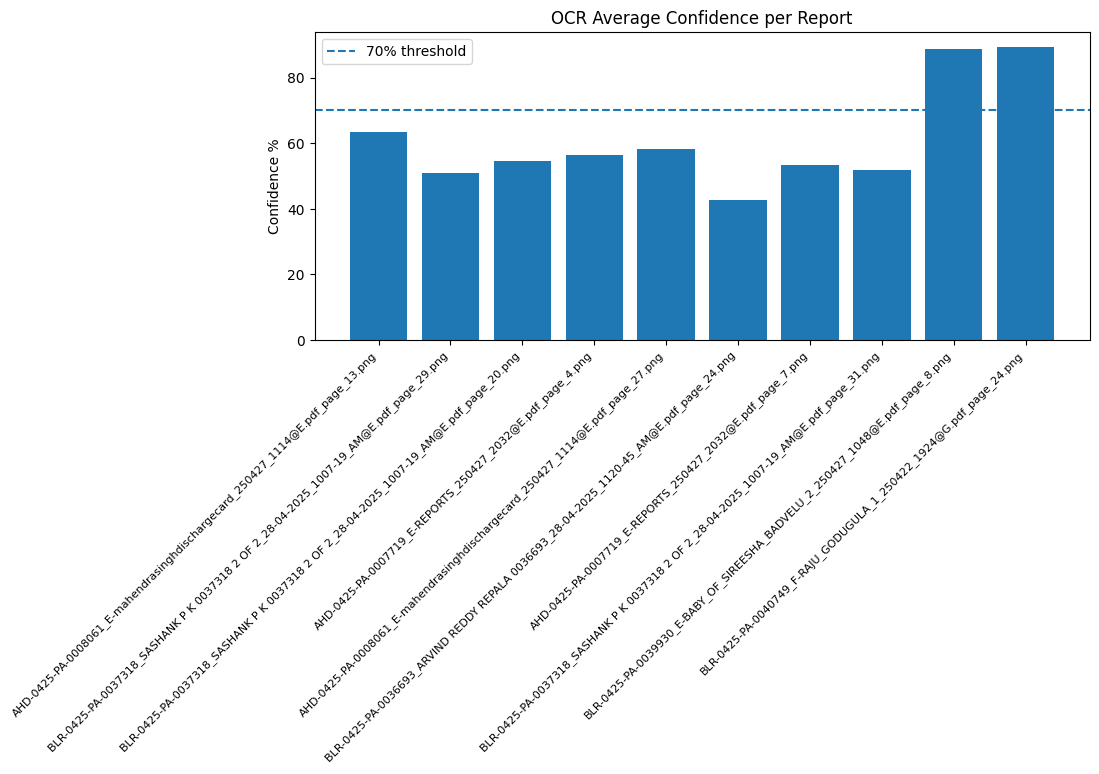

In [29]:
ocr_stats = evaluate_ocr_quality(REPORTS_DIR)

### 12.2Validate GPT-4o Outputs
---

In [24]:
def validate_explanation(result):
    """
    Check if Gemini produced a valid, complete explanation.
    Returns: (is_valid: bool, message: str)
    """

    # Handle parse error first
    if result.get("parse_error"):
        return False, "Invalid JSON (parse error)"

    exp = result.get('explanation', {})

    # Ensure explanation exists
    if not isinstance(exp, dict):
        return False, "Explanation is not a dictionary"

    # Required keys
    required = ['patient_summary', 'test_results', 'flags', 'next_steps', 'disclaimer']
    missing = [k for k in required if k not in exp]

    if missing:
        return False, f"Missing keys: {missing}"

    # Check test_results
    if not isinstance(exp.get('test_results'), list) or len(exp['test_results']) == 0:
        return False, "No valid test results extracted"

    # Check each test entry
    for test in exp['test_results']:
        if not isinstance(test, dict):
            return False, "Invalid test result format"

        for field in ['test_name', 'value', 'status']:
            if field not in test or not test.get(field):
                return False, f"Test missing required field: {field}"

    return True, "Valid"

##13. Save Corpus
---

In [25]:
import json
# Build corpus
corpus = []

for i, record in enumerate(validation_records):
    fname = record['filename']
    text_path = os.path.join(TEXT_DIR, Path(fname).stem + '.txt')

    text = ""
    if os.path.exists(text_path):
        try:
            with open(text_path, 'r', encoding='utf-8') as f:
                text = f.read()
        except Exception as e:
            print(f"[ERROR] Reading {fname}: {e}")

    corpus.append({
        'id'            : i,
        'filename'      : fname,
        'quality'       : record.get('quality', 'unknown'),
        'word_count'    : record.get('word_count', 0),
        'ocr_confidence': record.get('confidence', 0),
        'extracted_text': text,
        'usable'        : record.get('quality') in ('good', 'partial'),
    })

# Save corpus JSON
corpus_path = os.path.join(OUTPUT_DIR, 'bajaj_corpus.json')

with open(corpus_path, 'w', encoding='utf-8') as f:
    json.dump(corpus, f, indent=2, ensure_ascii=False)

# Copy to Drive safely
drive_dir = '/content/drive/MyDrive/medai_module3/'
os.makedirs(drive_dir, exist_ok=True)

try:
    shutil.copy(corpus_path, os.path.join(drive_dir, 'bajaj_corpus.json'))
except Exception as e:
    print(f"[ERROR] Copy failed: {e}")

# Stats
usable_count = sum(1 for r in corpus if r['usable'])
total = len(corpus)

print(f"\nCorpus saved      : {corpus_path}")
print(f"Total reports     : {total}")
print(f"Usable reports    : {usable_count} ({(usable_count/total*100):.0f}%)")
print(f"Copied to Drive   : {drive_dir}")


Corpus saved      : /content/bajaj_processed/bajaj_corpus.json
Total reports     : 425
Usable reports    : 415 (98%)
Copied to Drive   : /content/drive/MyDrive/medai_module3/


##14. Inference Function
---

This is the function that the Streamlit app calls when a user uploads a lab report.


In [26]:
def predict_report(image_path, patient_age=None, patient_gender=None, top_k_tests=10):
    """
    Complete inference function for Streamlit deployment.

    Args:
        image_path     : str  — path to uploaded report image
        patient_age    : int  — from Streamlit number_input
        patient_gender : str  — from Streamlit selectbox
        top_k_tests    : int  — max tests to display

    Returns:
        dict — explanation ready to render in Streamlit
    """
    # 1. Preprocess
    processed = preprocess_for_ocr(image_path)

    # 2. OCR
    raw_text = pytesseract.image_to_string(
        Image.fromarray(processed),
        config=TESS_CONFIG
    )
    clean_text = clean_ocr_text(raw_text)

    if len(clean_text.strip()) < 20:
        return {
            'error': 'Could not extract enough text from this image. '
                     'Please ensure the image is clear and well-lit.'
        }

    # 3. Gemini (replacing GPT-4o)
    explanation = explain_report(clean_text, patient_age, patient_gender)

    # Handle Gemini failure (VERY IMPORTANT)
    if isinstance(explanation, dict) and explanation.get("parse_error"):
        return {
            'error': 'Could not generate structured analysis. Please try again.',
            'raw_output': explanation.get('raw_response', '')
        }

    # Ensure explanation is valid
    if not isinstance(explanation, dict):
        return {'error': 'Invalid response from model.'}

    # 4. Trim results safely
    if 'test_results' in explanation and isinstance(explanation['test_results'], list):
        explanation['test_results'] = explanation['test_results'][:top_k_tests]

    return explanation